# Classification (Language ID from Audio Features)

This notebook implements the **Classification** stage of the ML Basics Final Project (Phase 2).  
It assumes you already extracted per-clip audio features (e.g., MFCC stats, spectral features, etc.) into a tabular file (CSV/Parquet/JSONL).

**What you’ll do here**
- Load your extracted feature table
- Split into **train/test (80/20) with stratification**
- Apply **normalization** (and optional **PCA**)
- Train **≥ 3 classifiers** (we provide 5)
- Report **Accuracy, Precision, Recall, F1 (macro & weighted)**
- Plot **Confusion Matrices** and compare models


## 0) Setup

If you’re missing packages, uncomment and run:

```bash
pip install -U numpy pandas scikit-learn matplotlib joblib
```


In [7]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

import joblib


## 1) Load extracted features

### Expected format
A single table where:
- each row = one audio clip
- columns = numeric features (e.g., `mfcc_1_mean`, `centroid_var`, ...)
- one column contains the label (language). Common names: `label`, `language`, `lang`, `y`.

You can start with CSV: `features.csv`.

**Tip:** Keep any ID/path columns (e.g., `filepath`) — we’ll drop non-numeric columns automatically.


In [ ]:
# CONFIG
DATA_PATH = Path("processed_features_dataset.csv")
label_col = "label"
RANDOM_STATE = 42

USE_PCA = True
PCA_VARIANCE_TO_KEEP = 0.95  # keep 95% explained variance (only used if USE_PCA=True)

OUTPUT_DIR = Path("artifacts")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [28]:
def load_feature_table(path: Path) -> pd.DataFrame:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Could not find {path.resolve()}.\n"
            "Put your extracted feature table next to this notebook, or update DATA_PATH."
        )
    return pd.read_csv(path)

df = load_feature_table(DATA_PATH)
print(df.shape)
df.head()


(10852, 51)


,mfcc_1_mean,mfcc_1_var,mfcc_2_mean,mfcc_2_var,mfcc_3_mean,mfcc_3_var,mfcc_4_mean,mfcc_4_var,mfcc_5_mean,mfcc_5_var,...,centroid_var,zcr_mean,zcr_var,chroma_mean,chroma_var,contrast_mean,contrast_var,label,gender,filename
0,-263.92203,18606.697,77.982285,3757.3372,-9.310464,984.79010,39.328022,945.08030,5.222437,355.08865,...,1.277559e+06,0.127055,0.007808,0.395074,0.095600,23.148505,163.087572,German,Male,810100147_male_german_voice02.mp3
1,-349.74377,26918.447,63.186960,3615.7522,-9.667652,981.03674,50.941124,904.13910,11.845338,385.06332,...,1.027629e+06,0.124588,0.008629,0.368092,0.102901,24.040477,160.237843,German,Male,810100147_male_german_voice02.mp3
2,-245.28510,19061.607,73.344010,3277.5037,-8.776618,1122.65160,47.934100,1196.81510,7.272524,265.86210,...,1.245263e+06,0.114661,0.009235,0.352566,0.099449,23.742645,158.019540,German,Male,810100147_male_german_voice02.mp3
3,-318.25030,27300.646,68.638030,4238.5645,3.514310,799.79070,29.387894,834.46576,-0.657580,582.34360,...,1.787097e+06,0.127870,0.009768,0.412828,0.093851,23.488550,153.645357,German,Male,810100147_male_german_voice02.mp3
4,-339.06280,33127.367,71.513080,4391.4937,-1.589328,1419.51620,25.225393,737.10250,0.498458,531.27940,...,1.657907e+06,0.120823,0.009985,0.391374,0.098067,24.110493,149.460309,German,Male,810100147_male_german_voice02.mp3


In [29]:
print("Label column:", label_col)
print("Classes:", df[label_col].unique())


Label column: label
Classes: ['German' 'Spanish' 'Italian' 'Korean']


### Quick sanity checks

label
Italian    2954
German     2675
Korean     2618
Spanish    2605
Name: count, dtype: int64

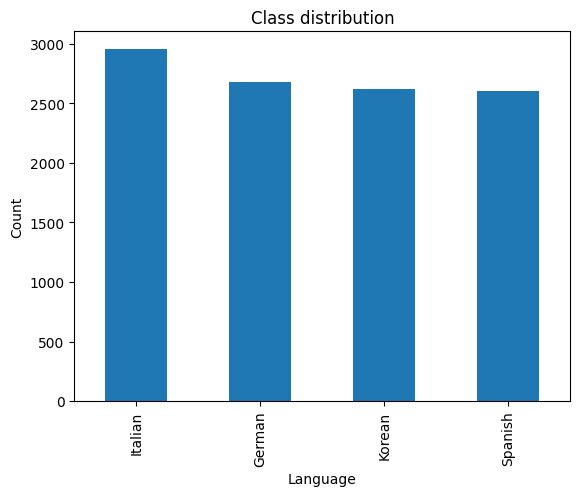

In [30]:
# Class balance
class_counts = df[label_col].value_counts()
display(class_counts)

ax = class_counts.plot(kind="bar")
ax.set_title("Class distribution")
ax.set_xlabel("Language")
ax.set_ylabel("Count")
plt.show()


In [31]:
# Separate X/y
y = df[label_col].astype(str)

# Keep only numeric columns as features (drop label and any non-numeric columns)
numeric_cols = df.drop(columns=[label_col]).select_dtypes(include=["number"]).columns.tolist()
if len(numeric_cols) == 0:
    raise ValueError("No numeric feature columns found. Make sure your extracted features are numeric.")

X = df[numeric_cols].copy()

print("X shape:", X.shape)
print("# numeric feature columns:", len(numeric_cols))


X shape: (10852, 48)
# numeric feature columns: 48


## 2) Train/test split (stratified 80/20)

We use `train_test_split(..., stratify=y, test_size=0.2)` to preserve label proportions.


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train class distribution:\n", y_train.value_counts(normalize=True).round(3))
print("Test class distribution:\n", y_test.value_counts(normalize=True).round(3))


Train: (8681, 48)  Test: (2171, 48)
Train class distribution:
 label
Italian    0.272
German     0.247
Korean     0.241
Spanish    0.240
Name: proportion, dtype: float64
Test class distribution:
 label
Italian    0.272
German     0.246
Korean     0.241
Spanish    0.240
Name: proportion, dtype: float64


## 3) Preprocessing pipeline

- **Impute** missing values (median)  
- **Standardize** features (zero mean, unit variance)  
- Optional **PCA** to reduce dimensionality

We’ll reuse the same preprocessing steps inside each model pipeline.


In [33]:
def make_preprocessor(use_pca: bool = False) -> Pipeline:
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
    if use_pca:
        steps.append(("pca", PCA(n_components=PCA_VARIANCE_TO_KEEP, svd_solver="full", random_state=RANDOM_STATE)))
    return Pipeline(steps)

preprocessor = make_preprocessor(USE_PCA)
preprocessor


,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


## 4) Models (≥ 3)

We include 5 common models:
- KNN
- SVM (RBF)
- Random Forest
- Logistic Regression
- MLP (small neural net)

You can remove any you don’t want, but keep at least 3.


In [ ]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "SVM_RBF": SVC(kernel="rbf", C=10, gamma="scale", probability=False, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE),
    "LogReg": LogisticRegression(max_iter=2000, n_jobs=None),
    "MLP": MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=800, random_state=RANDOM_STATE),
}

pipelines = {}
for name, clf in models.items():
    pipelines[name] = Pipeline([
        ("preprocess", preprocessor),
        ("clf", clf)
    ])

list(pipelines.keys())


['KNN', 'SVM_RBF', 'RandomForest', 'LogReg', 'MLP']

## 5) Train + Evaluate

We report:
- Accuracy
- Precision / Recall / F1 (macro)
- Precision / Recall / F1 (weighted)
- Full `classification_report`
- Confusion matrix for each model



KNN
              precision    recall  f1-score   support

      German     0.9944    0.9963    0.9953       535
     Italian     1.0000    0.9966    0.9983       591
      Korean     0.9943    0.9962    0.9952       524
     Spanish     1.0000    1.0000    1.0000       521

    accuracy                         0.9972      2171
   macro avg     0.9972    0.9973    0.9972      2171
weighted avg     0.9972    0.9972    0.9972      2171



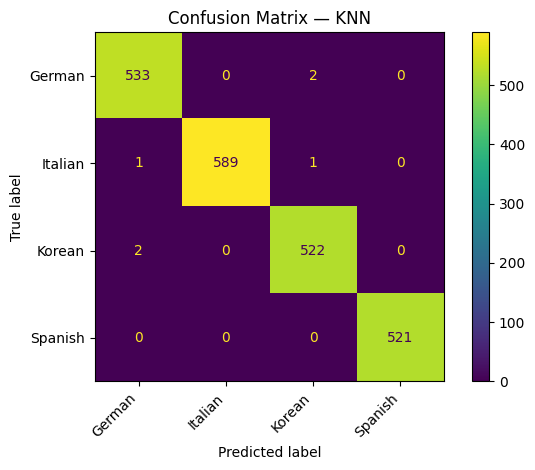


SVM_RBF
              precision    recall  f1-score   support

      German     0.9981    1.0000    0.9991       535
     Italian     1.0000    0.9983    0.9992       591
      Korean     1.0000    1.0000    1.0000       524
     Spanish     1.0000    1.0000    1.0000       521

    accuracy                         0.9995      2171
   macro avg     0.9995    0.9996    0.9996      2171
weighted avg     0.9995    0.9995    0.9995      2171



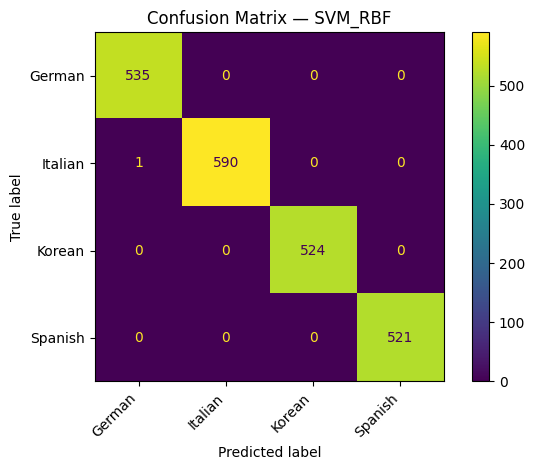


RandomForest
              precision    recall  f1-score   support

      German     0.9944    0.9981    0.9963       535
     Italian     1.0000    0.9966    0.9983       591
      Korean     0.9981    0.9981    0.9981       524
     Spanish     0.9981    0.9981    0.9981       521

    accuracy                         0.9977      2171
   macro avg     0.9976    0.9977    0.9977      2171
weighted avg     0.9977    0.9977    0.9977      2171



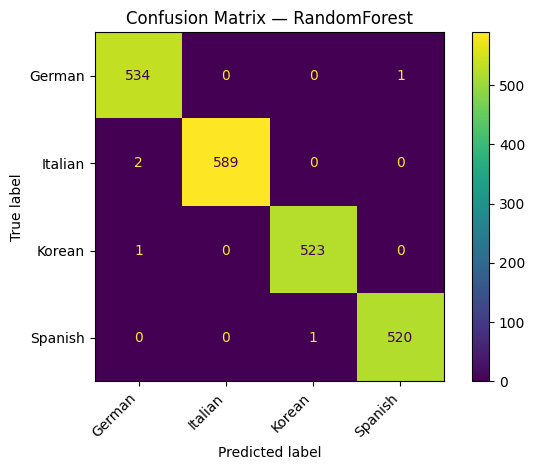


LogReg
              precision    recall  f1-score   support

      German     0.9924    0.9738    0.9830       535
     Italian     0.9800    0.9932    0.9866       591
      Korean     0.9771    0.9790    0.9781       524
     Spanish     0.9866    0.9885    0.9875       521

    accuracy                         0.9839      2171
   macro avg     0.9840    0.9836    0.9838      2171
weighted avg     0.9839    0.9839    0.9839      2171



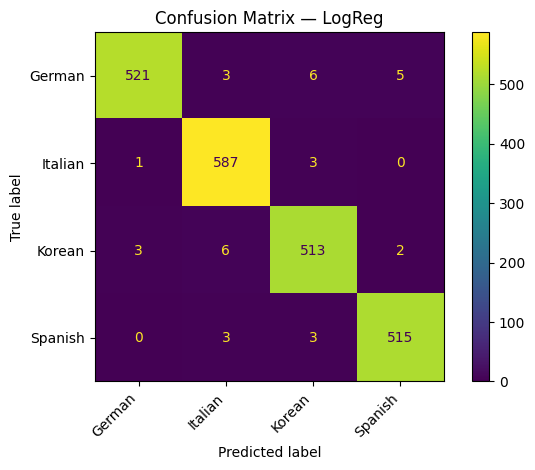


MLP
              precision    recall  f1-score   support

      German     1.0000    1.0000    1.0000       535
     Italian     1.0000    1.0000    1.0000       591
      Korean     1.0000    1.0000    1.0000       524
     Spanish     1.0000    1.0000    1.0000       521

    accuracy                         1.0000      2171
   macro avg     1.0000    1.0000    1.0000      2171
weighted avg     1.0000    1.0000    1.0000      2171



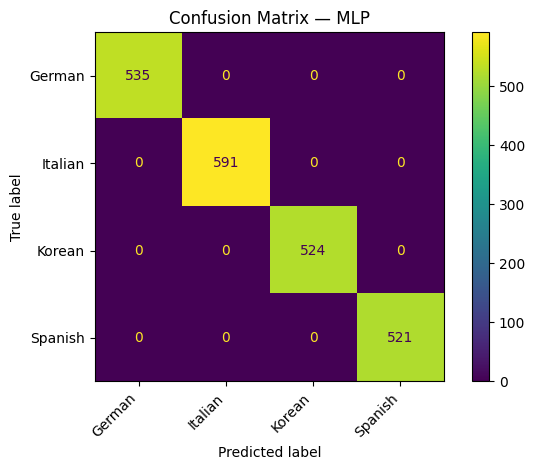

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
4,MLP,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,SVM_RBF,0.999539,0.999534,0.999577,0.999555,0.999540,0.999539,0.999539
2,RandomForest,0.997697,0.997646,0.997730,0.997686,0.997702,0.997697,0.997698
0,KNN,0.997236,0.997172,0.997265,0.997218,0.997242,0.997236,0.997238
3,LogReg,0.983878,0.984020,0.983639,0.983796,0.983934,0.983878,0.983872


In [35]:
def evaluate_model(name: str, pipe: Pipeline, X_test, y_test) -> dict:
    y_pred = pipe.predict(X_test)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    }

    print("\n" + "="*90)
    print(f"{name}")
    print("="*90)
    print(classification_report(y_test, y_pred, digits=4, zero_division=0))

    disp = ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        normalize=None,
        values_format="d"
    )
    disp.ax_.set_title(f"Confusion Matrix — {name}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return metrics

results = []
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    results.append(evaluate_model(name, pipe, X_test, y_test))

results_df = pd.DataFrame(results).sort_values(by="f1_macro", ascending=False)
results_df


### Model comparison (sorted by Macro F1)

Macro averages treat each class equally (good when class imbalance exists).
Weighted averages account for class frequency.


In [36]:
cols = [
    "model",
    "accuracy",
    "f1_macro",
    "precision_macro",
    "recall_macro",
    "f1_weighted",
]
display(results_df[cols].reset_index(drop=True))

best_model_name = results_df.iloc[0]["model"]
print("Best by macro F1:", best_model_name)


,model,accuracy,f1_macro,precision_macro,recall_macro,f1_weighted
0,MLP,1.000000,1.000000,1.000000,1.000000,1.000000
1,SVM_RBF,0.999539,0.999555,0.999534,0.999577,0.999539
2,RandomForest,0.997697,0.997686,0.997646,0.997730,0.997698
3,KNN,0.997236,0.997218,0.997172,0.997265,0.997238
4,LogReg,0.983878,0.983796,0.984020,0.983639,0.983872


Best by macro F1: MLP


In [37]:
y_shuf = y_train.sample(frac=1.0, random_state=42).reset_index(drop=True)
X_tr = X_train.reset_index(drop=True)

pipe = pipelines["SVM_RBF"]
pipe.fit(X_tr, y_shuf)
pred = pipe.predict(X_test)

from sklearn.metrics import accuracy_score
print("Shuffled-label accuracy:", accuracy_score(y_test, pred))


Shuffled-label accuracy: 0.24044219253800092


## 6) Save the best model pipeline

This saves the full pipeline (imputer + scaler (+ PCA) + classifier).  
Later you can load it and run `predict` on new feature rows.


In [ ]:
best_pipe = pipelines[best_model_name]

model_path = OUTPUT_DIR / f"best_model_{best_model_name}.joblib"
joblib.dump(
    {
        "pipeline": best_pipe,
        "feature_columns": numeric_cols,
        "label_col": label_col,
        "classes_": sorted(y.unique().tolist()),
        "use_pca": USE_PCA,
        "pca_variance": PCA_VARIANCE_TO_KEEP if USE_PCA else None,
    },
    model_path
)

print("Saved:", model_path.resolve())


## 7) Quick PCA visualization (2D)

If you want a 2D view of the separability in feature space, you can project to 2D with PCA.
This is *not required* for classification, but it’s useful for intuition and for the report.


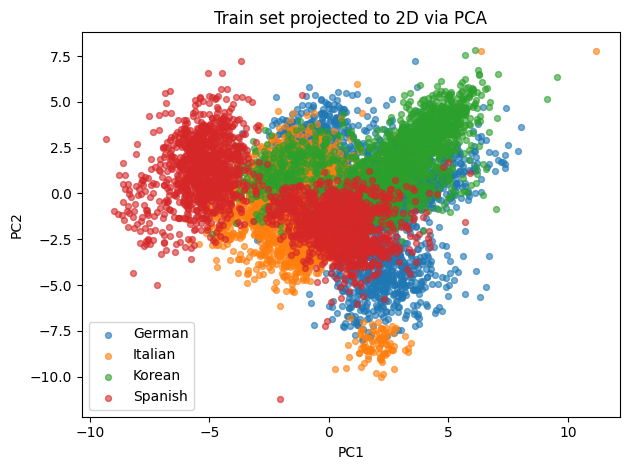

Explained variance (PC1+PC2): 0.3237


In [38]:
from sklearn.decomposition import PCA

# Fit preprocessing (imputer+scaler) on train only, then do PCA to 2D
prep_no_pca = make_preprocessor(use_pca=False)
X_train_scaled = prep_no_pca.fit_transform(X_train)
X_test_scaled = prep_no_pca.transform(X_test)

pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X2_train = pca2.fit_transform(X_train_scaled)

plt.figure()
for lang in sorted(y_train.unique()):
    idx = (y_train == lang).values
    plt.scatter(X2_train[idx, 0], X2_train[idx, 1], label=lang, alpha=0.6, s=18)
plt.title("Train set projected to 2D via PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

print("Explained variance (PC1+PC2):", pca2.explained_variance_ratio_.sum().round(4))


## 8)  Hyperparameter tuning

If you want better performance, tune hyperparameters with `GridSearchCV` or `RandomizedSearchCV`.
This can be time-consuming depending on dataset size.


In [ ]:
# Uncomment to tune one model (example: SVM)
# from sklearn.model_selection import GridSearchCV
#
# svm_pipe = pipelines["SVM_RBF"]
# param_grid = {
#     "clf__C": [0.1, 1, 10, 50],
#     "clf__gamma": ["scale", 0.01, 0.1, 1],
# }
# gs = GridSearchCV(svm_pipe, param_grid, scoring="f1_macro", cv=5, n_jobs=-1, verbose=1)
# gs.fit(X_train, y_train)
# print("Best params:", gs.best_params_)
# print("Best CV f1_macro:", gs.best_score_)
#
# tuned_svm = gs.best_estimator_
# _ = evaluate_model("SVM_RBF_Tuned", tuned_svm, X_test, y_test)
